<h1>Imports de las Librerias<h1>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

<h3>Segmentación de Clientes usando K-means con Técnica RFM<h3>

In [13]:
# Configuración de estilo
plt.style.use('ggplot')
sns.set_palette('viridis')

In [14]:

# Cargar los datos
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [15]:
# Ver las primeras filas para entender los datos
print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

<h1>1. Preparación de datos para RFM<h1>

<p>Convertimos las fechas si es necesario (en este dataset no hay columna de fecha, usaremos Customer ID como identificador y asumimos que cada fila es una transaccion y los agrupamos por Customer ID<p>


<p>Recency (R): Cuanto mas tiempo ha pasado desde su ultima compra.<p>
<p>Frequency (F): Con que frecuencia compran <p>
<p>Monetary (M): Cuanto dinero gastan<p>


In [16]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Amount (USD)': lambda x: x.sum(),  # Monetary value
    'Customer ID': lambda x: len(x),            # Frequency
    'Previous Purchases': 'max'                 # Proxy para Recency
}).rename(columns={
    'Purchase Amount (USD)': 'Monetary',
    'Customer ID': 'Frequency',
    'Previous Purchases': 'Recency'
}).reset_index()
rfm.head() 

,Customer ID,Monetary,Frequency,Recency
0,1,53,1,14
1,2,64,1,2
2,3,73,1,23
3,4,90,1,49
4,5,49,1,31


<p>Vamos a invertir la Recency para los valores mas altos para el RFM<p>

In [17]:
# Invertir Recency para que valores más altos signifiquen más reciente
rfm['Recency'] = rfm['Recency'].max() - rfm['Recency']
rfm.head()

,Customer ID,Monetary,Frequency,Recency
0,1,53,1,36
1,2,64,1,48
2,3,73,1,27
3,4,90,1,1
4,5,49,1,19


<h1>2.Vamos a Prepocesar los datos<h1>

<p>Ahora vamos a aplicar el algoritmo para normalizar las distribuciones.
<p>Despues vamos a estandalizar los datos para que todas las variables tengan la misma escala<p>

In [18]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

<p>Transforma cada valor con la fórmula log(1 + x)<p>

<p>Objetivo: Normalizar distribuciones sesgadas y reducir el impacto de valores extremos<p>

<h1>3.Ahora vamos a Determinar el numero optico de clusters<h1>

<p>Ahora vamos a usar el metodo del codo y de las siluetas para poder elegir el mejor numero de clusters que vamos a usar<p>

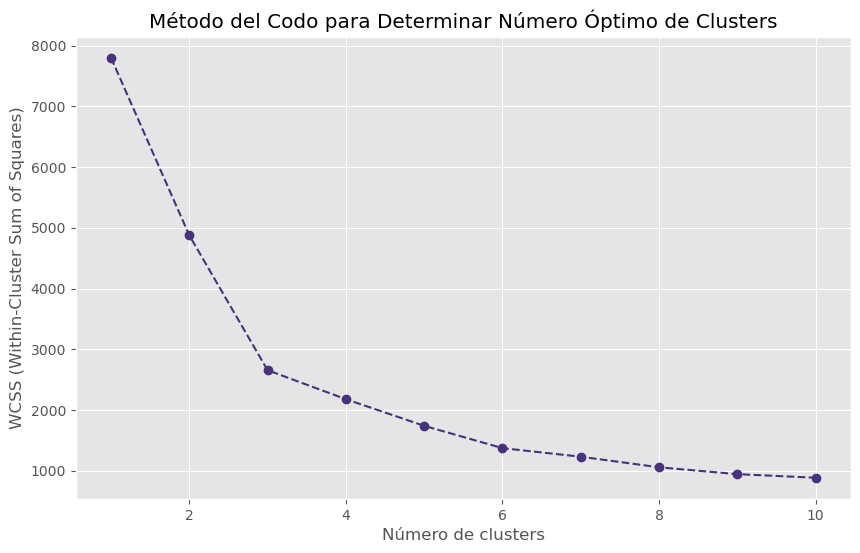

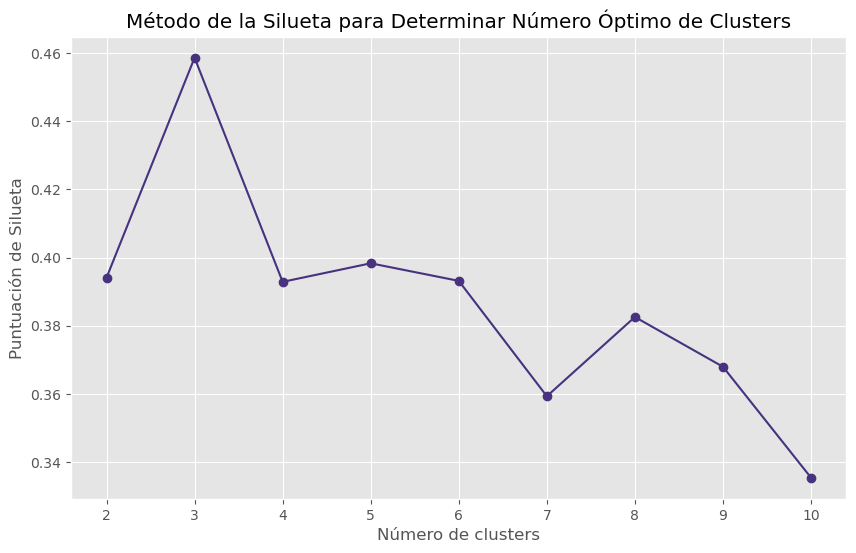

In [19]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para Determinar Número Óptimo de Clusters')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

# Método de la silueta
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Método de la Silueta para Determinar Número Óptimo de Clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Puntuación de Silueta')
plt.grid(True)
plt.show()

<h1>4.Ahora vamos a analizar cada clusters y sus estadisticas por cluster<h1>

<p>Ahora con la informacion de arriba vamos a crear 4 clusters basados en el analisis que nos dio en las graficas.<p>

<p>Ahora vamos a aplicar K-means con el numero optico de los clusers y para eso vamos a escoger 4 basados en los graficos de arriba<p>

In [20]:
n_clusters = 4  # Basado en los gráficos anteriores
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
kmeans.fit(rfm_scaled)

# Añadir las etiquetas de cluster al dataframe RFM
rfm['Cluster'] = kmeans.labels_

<h1>5.Ahora vamos a interpretar los cluters<h1>

<p>Para eso nos basamos en los valores medios de R,F,M, podemos asignar las etiquetas de cada cluster<p>
<p>Vamos a calcular las estadisticas descriptivas para cada cluster, vamos a visualizar las relaciones entre variables con pairplots y despues vamos a crear graficos de barras para comparar medias<p>

In [21]:
cluster_stats = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median', 'min', 'max'],
    'Frequency': ['mean', 'median', 'min', 'max'],
    'Monetary': ['mean', 'median', 'min', 'max'],
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'Count'})

print("Estadísticas por Cluster:")
print(cluster_stats)

Estadísticas por Cluster:
           Recency                Frequency                  Monetary         \
              mean median min max      mean median min max       mean median   
Cluster                                                                        
0        12.530511   12.0   4  20       1.0    1.0   1   1  74.333748   74.0   
1        27.595588   27.0   4  49       1.0    1.0   1   1  33.049020   33.0   
2         2.407583    2.0   0   7       1.0    1.0   1   1  58.964455   57.5   
3        35.337009   35.0  21  49       1.0    1.0   1   1  74.470021   75.0   

                 Count  
        min  max count  
Cluster                 
0        44  100   803  
1        20   49  1224  
2        20  100   422  
3        46  100  1451  


<h1>6.Ahora vamos a unir los segmentos con los datos originales para su analisis adicionar<h1>

<p>Ahora vamos a asignar etiquetas descriptivas a cada clsuter basados en sus caracteristicas RFM y despues lo vamos a analizar las distribuciones de segmentos.<p>

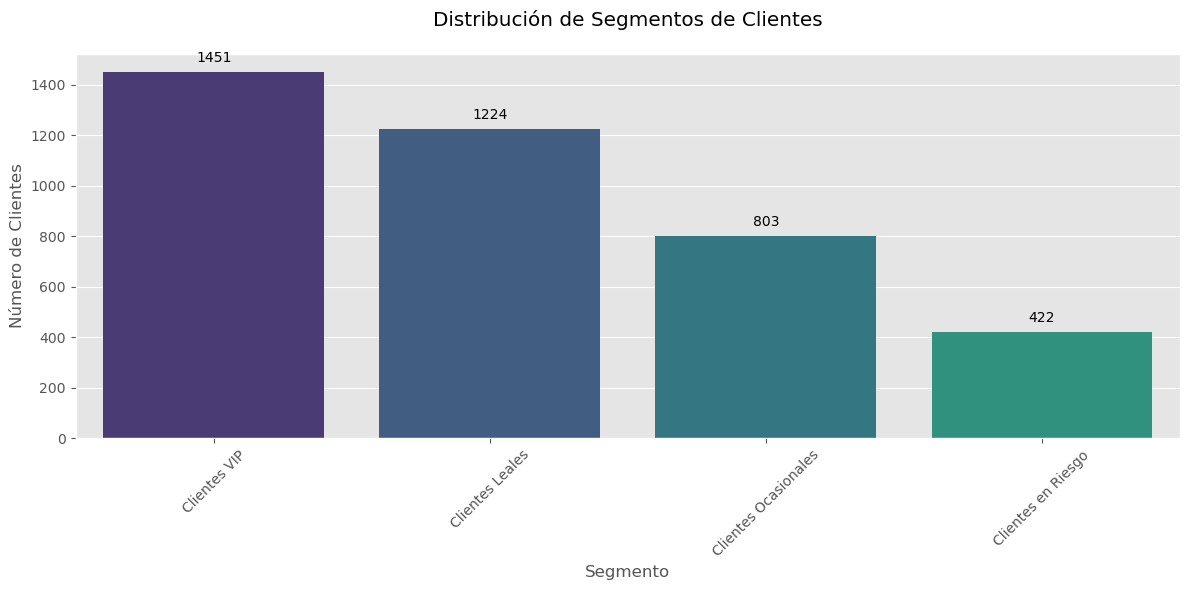

In [22]:
cluster_labels = {
    0: 'Clientes Ocasionales',
    1: 'Clientes Leales',
    2: 'Clientes en Riesgo',
    3: 'Clientes VIP'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

# Visualización mejorada de la distribución de segmentos
plt.figure(figsize=(12, 6))
segment_counts = rfm['Segment'].value_counts().sort_values(ascending=False)
ax = sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index, legend=False)
plt.title('Distribución de Segmentos de Clientes', pad=20)
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)

# Añadir etiquetas de valor encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

<h1>7.Vamos a visualizar en 3D los clusters<h1>

<p>Despues de interpretar los clusters, vamos a unir los segmentos con los datos originales para ver que nos da, despues de unir vamos a analizr las preferencias de categorias por segmentos y luego las vamos a comparar los montos de compras entre segmentos.<p>

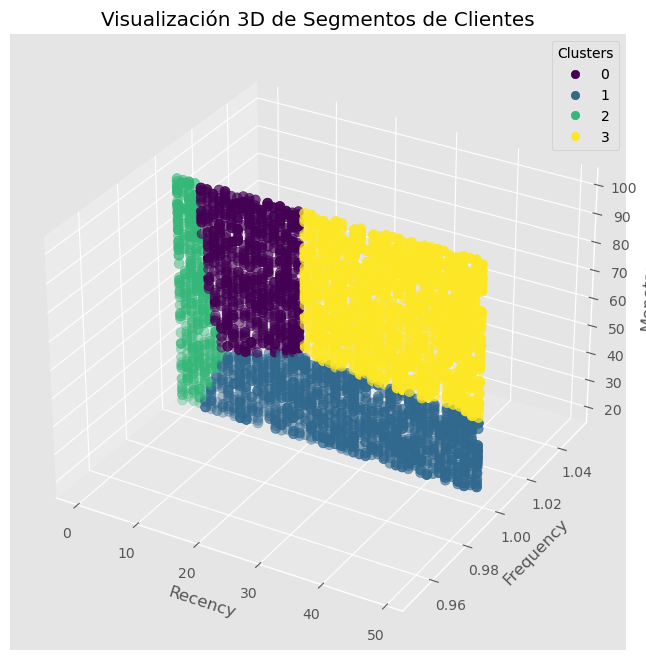

In [23]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
                     c=rfm['Cluster'], cmap='viridis', s=50)

ax.set_title('Visualización 3D de Segmentos de Clientes')
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

# Crear leyenda
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()

<h1>8.Vamos a analizar detalladamente cada segmento<h1>

<p>Para eso vamos a unir los segmentos con los datos originales para ver mejor<p>

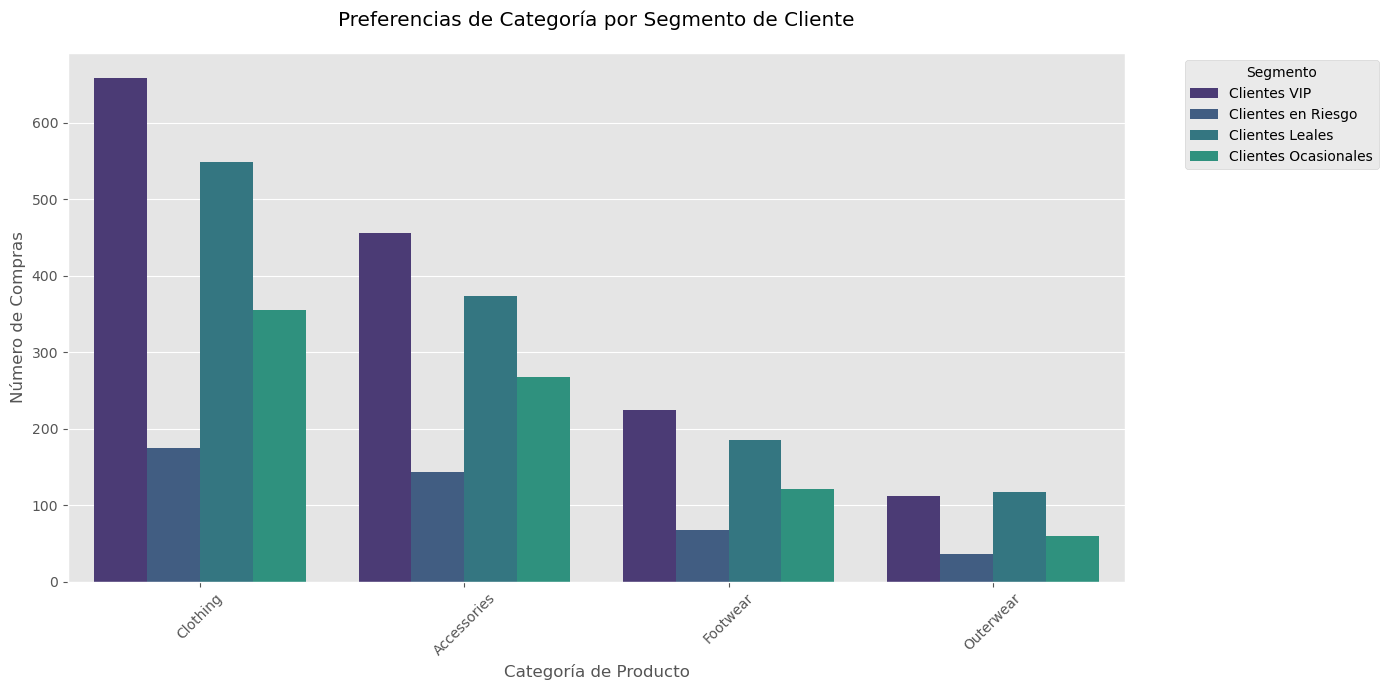

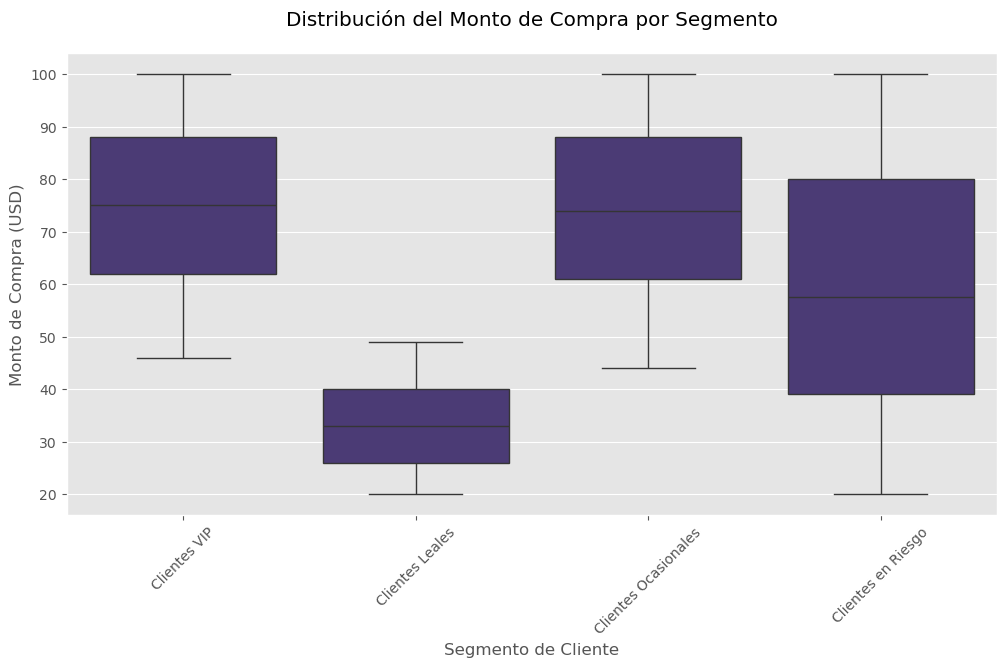

In [24]:
df_segmented = df.merge(rfm[['Customer ID', 'Segment']], on='Customer ID', how='left')

# Análisis de categorías preferidas por segmento
plt.figure(figsize=(14, 7))
sns.countplot(data=df_segmented, x='Category', hue='Segment', 
              order=df_segmented['Category'].value_counts().index)
plt.title('Preferencias de Categoría por Segmento de Cliente', pad=20)
plt.xlabel('Categoría de Producto')
plt.ylabel('Número de Compras')
plt.xticks(rotation=45)
plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Análisis de monto de compra por segmento
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_segmented, x='Segment', y='Purchase Amount (USD)', 
            order=['Clientes VIP', 'Clientes Leales', 'Clientes Ocasionales', 'Clientes en Riesgo'])
plt.title('Distribución del Monto de Compra por Segmento', pad=20)
plt.xlabel('Segmento de Cliente')
plt.ylabel('Monto de Compra (USD)')
plt.xticks(rotation=45)
plt.show()

<h1>9.Vamos a guardar los resultados fuera en formato csv<h1>

<p>Guardaremos en varios csv los datos que hemos obtenidos.<p>

In [25]:
rfm.to_csv('customer_segments_rfm.csv', index=False)
df_segmented.to_csv('shopping_trends_segmented.csv', index=False)

print("Análisis completado y archivos guardados.")

Análisis completado y archivos guardados.


<h1>Con PCA<h1>

<p>Con PCA vamos a reducir a 2 dimensiones para tener una visualizacion mas simple, podemos capturar las relaciones mas complejas entre las variables que tenemos, podemos interpretar directamente(se necesita un analisis de componenetes) y por ultimo es util cuando hay muchas variables(aunque en RFM son solo 3).<p>

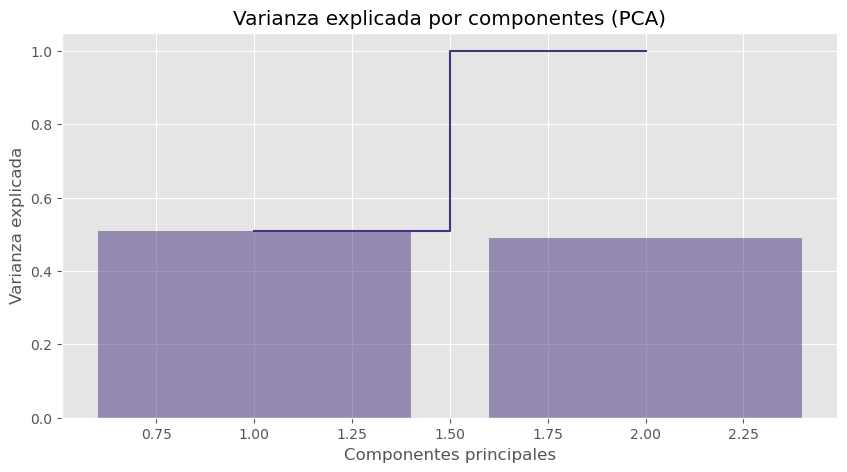

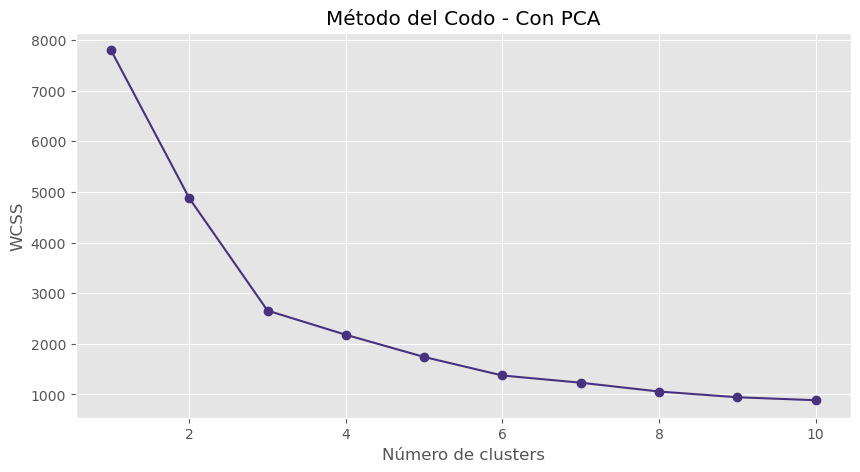

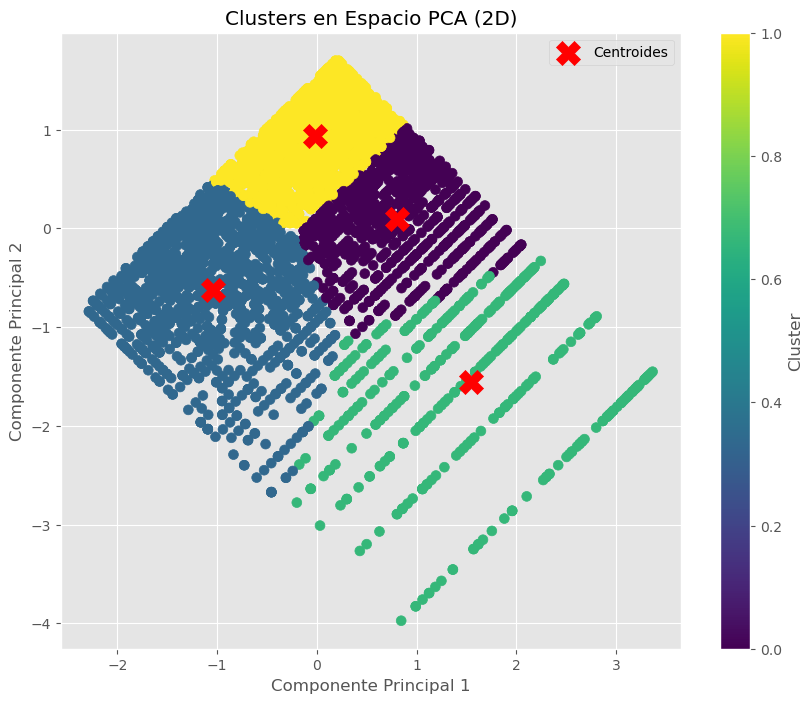


Comparación de asignaciones de clusters:
Con PCA               Clientes Leales  Clientes Ocasionales  Clientes VIP  \
Sin PCA                                                                     
Clientes Leales                  1224                     0             0   
Clientes Ocasionales                0                   803             0   
Clientes VIP                        0                     0          1451   
Clientes en Riesgo                  0                     0             0   

Con PCA               Clientes en Riesgo  
Sin PCA                                   
Clientes Leales                        0  
Clientes Ocasionales                   0  
Clientes VIP                           0  
Clientes en Riesgo                   422  


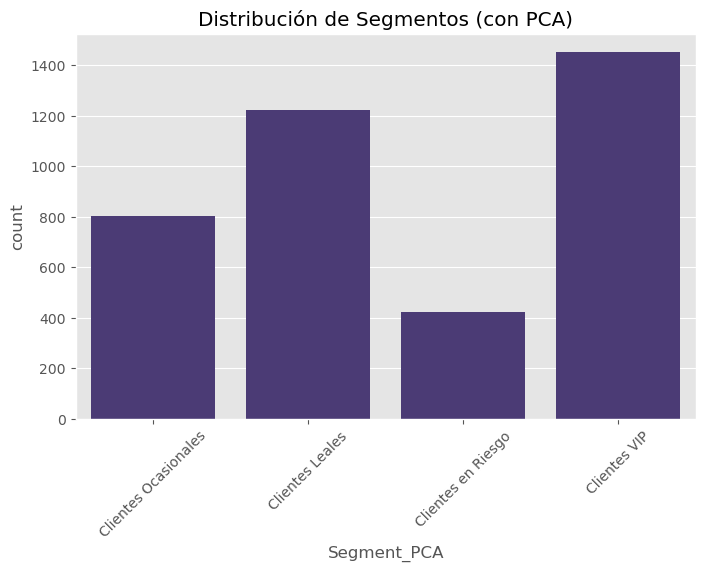


Componentes PCA:
      Recency  Frequency  Monetary
PC1 -0.707107        0.0  0.707107
PC2  0.707107       -0.0  0.707107


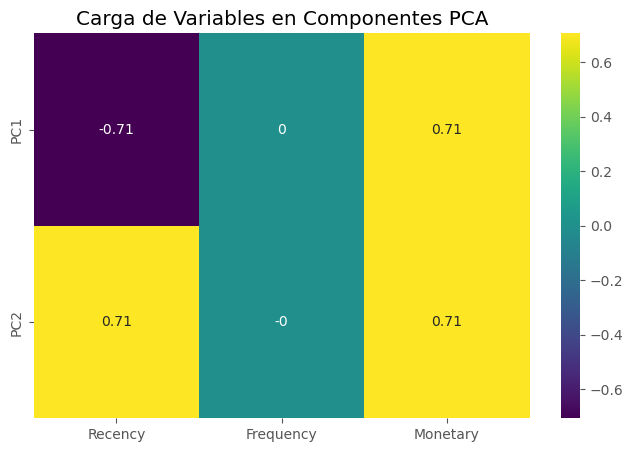

In [30]:
# 1. Usaremos el mismo preprocesamiento (rfm_scaled)

# 2. Aplicar PCA
pca = PCA(n_components=2)  # Reducimos a 2 dimensiones
rfm_pca = pca.fit_transform(rfm_scaled)

# 3. Visualizar varianza explicada
plt.figure(figsize=(10, 5))
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.5, align='center')
plt.step(range(1, 3), np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Varianza explicada')
plt.xlabel('Componentes principales')
plt.title('Varianza explicada por componentes (PCA)')
plt.show()

# 4. Determinar número óptimo de clusters en espacio PCA
wcss_pca = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_pca)
    wcss_pca.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss_pca, marker='o')
plt.title('Método del Codo - Con PCA')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

# 5. Aplicar K-means en espacio PCA (usaremos 4 clusters para comparar)
kmeans_pca = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_pca.fit(rfm_pca)
rfm['Cluster_PCA'] = kmeans_pca.labels_

# 6. Visualizar clusters en espacio PCA
plt.figure(figsize=(10, 8))
plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1], c=rfm['Cluster_PCA'], cmap='viridis', s=50)
plt.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], 
            s=300, c='red', marker='X', label='Centroides')
plt.title('Clusters en Espacio PCA (2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.colorbar(label='Cluster')
plt.show()

# 7. Analizar clusters PCA
# Define cluster_names using the existing cluster_labels
cluster_names = cluster_labels

rfm['Segment_PCA'] = rfm['Cluster_PCA'].map(cluster_names)

# Comparar asignaciones con/sin PCA
comparison = pd.crosstab(rfm['Segment'], rfm['Segment_PCA'], 
                        rownames=['Sin PCA'], 
                        colnames=['Con PCA'])
print("\nComparación de asignaciones de clusters:")
print(comparison)

# 8. Visualizar distribución de segmentos PCA
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x='Segment_PCA', order=cluster_names.values())
plt.title('Distribución de Segmentos (con PCA)')
plt.xticks(rotation=45)
plt.show()

# 9. Analizar componentes
print("\nComponentes PCA:")
components = pd.DataFrame(pca.components_, columns=['Recency', 'Frequency', 'Monetary'], index=['PC1', 'PC2'])
print(components)

# Visualizar carga de variables en componentes
plt.figure(figsize=(8, 5))
sns.heatmap(components, annot=True, cmap='viridis')
plt.title('Carga de Variables en Componentes PCA')
plt.show()

<h1>Sin PCA<h1>

Para sin PCA, nos va a trabajar directamente con las 3 dimensiones del RFM, tambien nos va a interpretar y mantener las metricas originales y nos va a dar una visualizacion que nos va a requerir unos multiples graficos 2D o 3D<p>

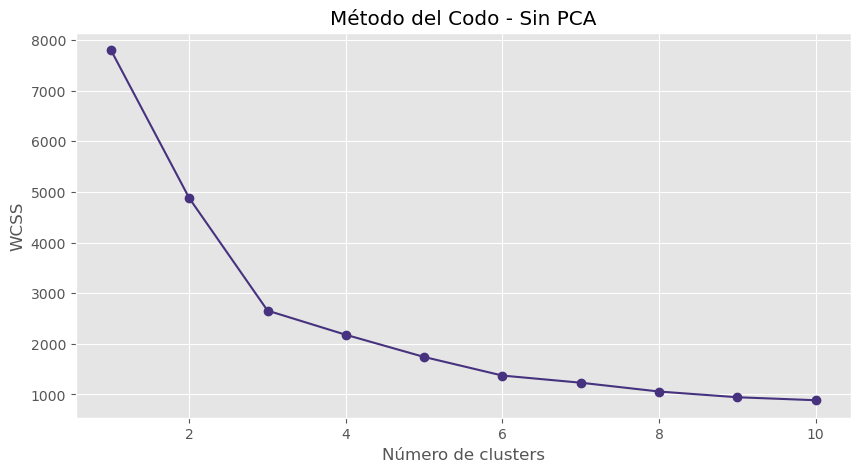

Estadísticas por Cluster (sin PCA):
           Recency                Frequency                  Monetary         \
              mean median min max      mean median min max       mean median   
Cluster                                                                        
0        12.530511   12.0   4  20       1.0    1.0   1   1  74.333748   74.0   
1        27.595588   27.0   4  49       1.0    1.0   1   1  33.049020   33.0   
2         2.407583    2.0   0   7       1.0    1.0   1   1  58.964455   57.5   
3        35.337009   35.0  21  49       1.0    1.0   1   1  74.470021   75.0   

                 Count  
        min  max count  
Cluster                 
0        44  100   803  
1        20   49  1224  
2        20  100   422  
3        46  100  1451  


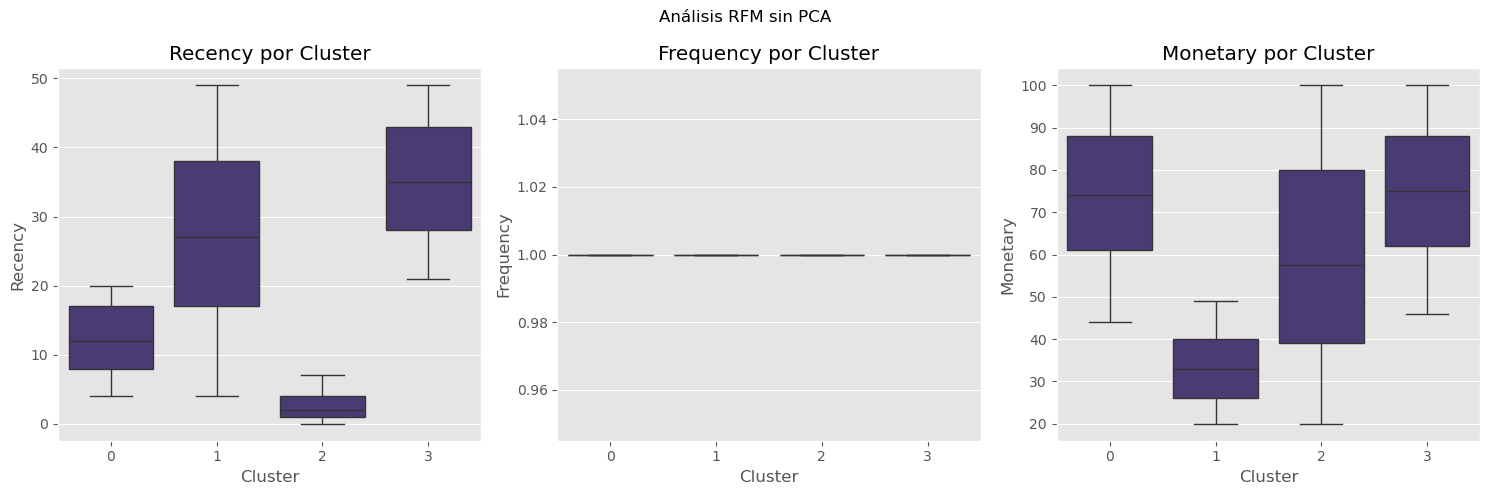

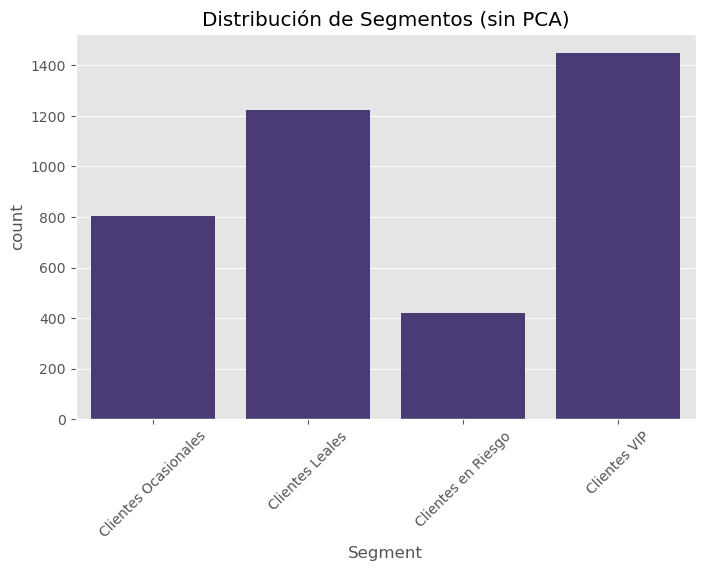

In [ ]:
# Cargar datos
df = pd.read_csv('shopping_trends.csv')

# 1. Crear dataset RFM
rfm = df.groupby('Customer ID').agg({
    'Purchase Amount (USD)': 'sum',      # Monetary
    'Customer ID': 'count',              # Frequency
    'Previous Purchases': 'max'          # Proxy para Recency (lo invertiremos)
}).rename(columns={
    'Purchase Amount (USD)': 'Monetary',
    'Customer ID': 'Frequency',
    'Previous Purchases': 'Recency'
}).reset_index()

# Invertir Recency para que mayor valor signifique más reciente
rfm['Recency'] = rfm['Recency'].max() - rfm['Recency']

# 2. Preprocesamiento
# Aplicar logaritmo para normalizar distribuciones
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Estandarizar
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 3. Determinar número óptimo de clusters
# Método del codo
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo - Sin PCA')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Aplicar K-means (usaremos 4 clusters)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_

# 5. Analizar clusters
cluster_stats = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'median', 'min', 'max'],
    'Frequency': ['mean', 'median', 'min', 'max'],
    'Monetary': ['mean', 'median', 'min', 'max'],
    'Customer ID': 'count'
}).rename(columns={'Customer ID': 'Count'})

print("Estadísticas por Cluster (sin PCA):")
print(cluster_stats)

# 6. Visualización
plt.figure(figsize=(15, 5))
plt.suptitle('Análisis RFM sin PCA')

plt.subplot(1, 3, 1)
sns.boxplot(data=rfm, x='Cluster', y='Recency')
plt.title('Recency por Cluster')

plt.subplot(1, 3, 2)
sns.boxplot(data=rfm, x='Cluster', y='Frequency')
plt.title('Frequency por Cluster')

plt.subplot(1, 3, 3)
sns.boxplot(data=rfm, x='Cluster', y='Monetary')
plt.title('Monetary por Cluster')

plt.tight_layout()
plt.show()

# 7. Asignar nombres a los clusters
cluster_names = {
    0: 'Clientes Ocasionales',
    1: 'Clientes Leales',
    2: 'Clientes en Riesgo',
    3: 'Clientes VIP'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

# Visualizar distribución de segmentos
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x='Segment', order=cluster_names.values())
plt.title('Distribución de Segmentos (sin PCA)')
plt.xticks(rotation=45)
plt.show()

<h1>Conclusion<h1>

<p>Para el analisis RFM con solo 3 variables, el metodo sin PCA es util por su interpretabilidad directa. PCA es mas util cuando:<p>

<p>*Cuando hay muchas variables de entrada.<p>
<p>*Se necesite una visualizacion 2D mas clara<p>
<p>*Cuando exista una alta correlacion entre variables originales<p>
